# 第3章 ロジットモデルの推定

自動車市場のデータを用いて、ロジットモデルによる需要推定を行う。
OLS、BLP操作変数、Differentiation IVによる推定を比較する。

## 1. Pythonに関する下準備

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings

warnings.filterwarnings('ignore')

# 日本語フォント設定
for font_name in ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                   'IPAexGothic', 'Noto Sans CJK JP', 'Yu Gothic']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.family'] = font_name
        break
    except ValueError:
        continue

# パス設定
base_dir = Path('..')
data_dir = base_dir / 'data'
intermediate_dir = base_dir / 'intermediate'
output_dir = base_dir / 'output'
output_dir.mkdir(exist_ok=True)
intermediate_dir.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. データの読み込みとクリーニング

In [2]:
# 自動車データ
data = pd.read_csv(data_dir / 'CleanData_20180222_nippyo.csv')

# 家計数データ
dataHH = pd.read_csv(data_dir / 'HHsize.csv', encoding='utf-8-sig',
                     thousands=',')

# CPI
dataCPI = pd.read_csv(data_dir / 'zni2015s.csv', encoding='shift-jis')
dataCPI = dataCPI.iloc[5:56].copy()
dataCPI = dataCPI.rename(columns={'類・品目': 'year', '総合': 'cpi'})
dataCPI = dataCPI[['year', 'cpi']].copy()
dataCPI['year'] = pd.to_numeric(dataCPI['year'].str.strip(), errors='coerce')
dataCPI['cpi'] = pd.to_numeric(dataCPI['cpi'], errors='coerce')
dataCPI = dataCPI.dropna()

print(f"自動車データ: {data.shape}")
print(f"家計データ: {dataHH.shape}")
print(f"CPIデータ: {dataCPI.shape}")


自動車データ: (1961, 37)
家計データ: (42, 2)
CPIデータ: (51, 2)


In [3]:
# データクリーニング
# 必要な変数のみをキープ
data = data[['Maker', 'Type', 'Name', 'Year', 'Sales', 'Model',
             'Nippyo', 'price', 'kata',
             'weight', 'capacity', 'FuelType', 'FuelEfficiency', 'HorsePower',
             'overall_length', 'overall_width', 'overall_height']].copy()
data = data.rename(columns={'Year': 'year'})

# 家計サイズをマージ
data = data.merge(dataHH, on='year', how='left')

# CPIをマージ
data = data.merge(dataCPI, on='year', how='left')

# 燃費が欠損しているデータを落とす
data = data.dropna(subset=['FuelEfficiency'])

# 価格の実質化（2016年基準）。単位を100万円に変換
cpi2016 = dataCPI.loc[dataCPI['year'] == 2016, 'cpi'].values[0]
data['price'] = data['price'] / (data['cpi'] / cpi2016)
data['price'] = data['price'] / 100
data = data.drop(columns=['cpi'])

# サイズと馬力/重量比を定義
data['size'] = (data['overall_length'] / 1000) * (data['overall_width'] / 1000) * (data['overall_height'] / 1000)
data['hppw'] = data['HorsePower'] / data['weight']
data = data.drop(columns=['HorsePower', 'weight', 'overall_length', 'overall_width', 'overall_height'])

# 車種IDを作成
data['NameID'] = data.groupby('Name').ngroup() + 1

# マーケットシェアとOutside option shareを定義
data['inside_total'] = data.groupby('year')['Sales'].transform('sum')
data['outside_total'] = data['HH'] - data['inside_total']
data['share'] = data['Sales'] / data['HH']
data['share0'] = data['outside_total'] / data['HH']
data = data.drop(columns=['inside_total', 'outside_total'])

print(f"加工後のデータ: {data.shape}")
print(f"年数: {data['year'].nunique()}")
print(f"車種数: {data['NameID'].nunique()}")


加工後のデータ: (1823, 18)
年数: 11
車種数: 260


### 操作変数の構築

In [4]:
# BLP操作変数とGandhi-Houde Differentiation IVを構築

# マーケット・企業レベルの和と二乗和
for var in ['hppw', 'FuelEfficiency', 'size']:
    data[f'{var}_sum_own'] = data.groupby(['year', 'Maker'])[var].transform('sum')
    data[f'{var}_sqr_sum_own'] = data.groupby(['year', 'Maker'])[var].transform(lambda x: (x**2).sum())

data['group_n'] = data.groupby(['year', 'Maker'])['Sales'].transform('count')

# マーケットレベルの和と二乗和
for var in ['hppw', 'FuelEfficiency', 'size']:
    data[f'{var}_sum_mkt'] = data.groupby('year')[var].transform('sum')
    data[f'{var}_sqr_sum_mkt'] = data.groupby('year')[var].transform(lambda x: (x**2).sum())

data['mkt_n'] = data.groupby('year')['Sales'].transform('count')

# BLP操作変数
for var in ['hppw', 'FuelEfficiency', 'size']:
    data[f'iv_BLP_own_{var}'] = data[f'{var}_sum_own'] - data[var]
    data[f'iv_BLP_other_{var}'] = data[f'{var}_sum_mkt'] - data[f'{var}_sum_own']

# Differentiation IV
for var in ['hppw', 'FuelEfficiency', 'size']:
    data[f'iv_GH_own_{var}'] = (
        (data['group_n'] - 1) * data[var]**2 +
        (data[f'{var}_sqr_sum_own'] - data[var]**2) -
        2 * data[var] * (data[f'{var}_sum_own'] - data[var])
    )
    data[f'iv_GH_other_{var}'] = (
        (data['mkt_n'] - data['group_n']) * data[var]**2 +
        (data[f'{var}_sqr_sum_mkt'] - data[f'{var}_sqr_sum_own']) -
        2 * data[var] * (data[f'{var}_sum_mkt'] - data[f'{var}_sum_own'])
    )

# 不要な列を削除
drop_cols = [c for c in data.columns if c.endswith('_sum_own') or c.endswith('_sum_mkt')
             or c.endswith('_sqr_sum_own') or c.endswith('_sqr_sum_mkt')]
data = data.drop(columns=drop_cols + ['mkt_n', 'group_n'])

# 保存
data.to_csv(intermediate_dir / 'data_cleaned.csv', index=False)
print("data_cleaned.csv を保存しました。")
print(f"操作変数列: {[c for c in data.columns if c.startswith('iv_')]}")


data_cleaned.csv を保存しました。
操作変数列: ['iv_BLP_own_hppw', 'iv_BLP_other_hppw', 'iv_BLP_own_FuelEfficiency', 'iv_BLP_other_FuelEfficiency', 'iv_BLP_own_size', 'iv_BLP_other_size', 'iv_GH_own_hppw', 'iv_GH_other_hppw', 'iv_GH_own_FuelEfficiency', 'iv_GH_other_FuelEfficiency', 'iv_GH_own_size', 'iv_GH_other_size']


## 3. 記述統計と基礎的な分析

In [5]:
# 日評自動車のデータ
data_NIPPYO = data[data['Nippyo'] == 1][['Sales', 'price', 'hppw', 'FuelEfficiency', 'size']].copy()
data_NIPPYO['log_sales'] = np.log(data_NIPPYO['Sales'])
data_NIPPYO['log_price'] = np.log(data_NIPPYO['price'])

# OLS
X_intro = sm.add_constant(data_NIPPYO[['log_price', 'hppw', 'FuelEfficiency', 'size']])
ols_intro = sm.OLS(data_NIPPYO['log_sales'], X_intro).fit(cov_type='HC1')

print("イントロダクションのOLS推定:")
print(ols_intro.summary2().tables[1].to_string())

# 記述統計
desc = data[['Sales', 'price', 'FuelEfficiency', 'size', 'hppw']].describe()
print("\n記述統計:")
print(desc.round(3).to_string())
desc.round(3).to_csv(output_dir / 'tab3_1_data_summary.txt', sep='\t')


イントロダクションのOLS推定:
                   Coef.  Std.Err.         z         P>|z|     [0.025    0.975]
const           5.762112  1.061269  5.429456  5.652619e-08   3.682063  7.842161
log_price      -1.248276  0.309545 -4.032616  5.515927e-05  -1.854973 -0.641579
hppw           -4.196852  3.976218 -1.055488  2.912021e-01 -11.990097  3.596393
FuelEfficiency  0.088603  0.028389  3.121082  1.801878e-03   0.032963  0.144244
size            0.306896  0.058893  5.211099  1.877253e-07   0.191468  0.422323

記述統計:
            Sales     price  FuelEfficiency      size      hppw
count    1823.000  1823.000        1823.000  1823.000  1823.000
mean    24586.387     2.530          16.160    11.505     0.099
std     40195.267     1.827           5.551     2.482     0.036
min        10.000     0.705           5.500     5.909     0.045
25%      2975.000     1.417          12.000     9.586     0.077
50%      8544.000     2.050          15.400    11.473     0.093
75%     27323.500     2.869          19.400    1

## 4. ロジットモデルの推定とその応用

In [6]:
# 被説明変数
data['logit_share'] = np.log(data['share']) - np.log(data['share0'])

# OLS
X_ols = sm.add_constant(data[['price', 'hppw', 'FuelEfficiency', 'size']])
ols = sm.OLS(data['logit_share'], X_ols).fit(cov_type='HC1')

# IV推定: BLP IV
endog = data[['price']]
exog = sm.add_constant(data[['hppw', 'FuelEfficiency', 'size']])
instruments = data[['iv_BLP_own_hppw', 'iv_BLP_own_FuelEfficiency', 'iv_BLP_own_size',
                     'iv_BLP_other_hppw', 'iv_BLP_other_FuelEfficiency', 'iv_BLP_other_size']]

iv_BLP = IV2SLS(data['logit_share'], exog, endog, instruments).fit(cov_type='robust')

# IV推定: GH IV
instruments_GH = data[['iv_GH_own_hppw', 'iv_GH_own_FuelEfficiency', 'iv_GH_own_size',
                         'iv_GH_other_hppw', 'iv_GH_other_FuelEfficiency', 'iv_GH_other_size']]

iv_GH = IV2SLS(data['logit_share'], exog, endog, instruments_GH).fit(cov_type='robust')

# 結果表示
print("ロジットモデルの推定結果:")
result_table = pd.DataFrame({
    'OLS': ols.params,
    'IV_BLP': iv_BLP.params.reindex(ols.params.index),
    'IV_GH': iv_GH.params.reindex(ols.params.index)
})
print(result_table.round(4).to_string())

result_se = pd.DataFrame({
    'OLS_se': ols.bse,
    'IV_BLP_se': iv_BLP.std_errors.reindex(ols.params.index),
    'IV_GH_se': iv_GH.std_errors.reindex(ols.params.index)
})
print("\n標準誤差:")
print(result_se.round(4).to_string())

result_table.round(4).to_csv(output_dir / 'tab3_2_tbl_logit_iv.txt', sep='\t')


ロジットモデルの推定結果:
                    OLS   IV_BLP    IV_GH
const          -12.2548 -12.3234 -12.9727
price           -0.2551  -0.2835  -0.5521
hppw            -0.6542   0.2129   8.4256
FuelEfficiency   0.1301   0.1298   0.1268
size             0.1822   0.1874   0.2363

標準誤差:
                OLS_se  IV_BLP_se  IV_GH_se
const           0.3648     0.3815    0.3921
price           0.0258     0.0669    0.0804
hppw            1.2843     2.2943    2.6339
FuelEfficiency  0.0097     0.0097    0.0096
size            0.0189     0.0211    0.0222


### 自己価格弾力性の計算

In [7]:
# 自己価格弾力性
alpha_ols = ols.params['price']
alpha_blp = iv_BLP.params['price']
alpha_gh = iv_GH.params['price']

data['own_elas_ols'] = alpha_ols * data['price'] * (1 - data['share'])
data['own_elas_ivblp'] = alpha_blp * data['price'] * (1 - data['share'])
data['own_elas_ivgh'] = alpha_gh * data['price'] * (1 - data['share'])

elas_desc = data[['own_elas_ols', 'own_elas_ivblp', 'own_elas_ivgh']].describe()
print("自己価格弾力性の記述統計:")
print(elas_desc.round(4).to_string())
elas_desc.round(4).to_csv(output_dir / 'tab3_3_own_elas.txt', sep='\t')


自己価格弾力性の記述統計:
       own_elas_ols  own_elas_ivblp  own_elas_ivgh
count     1823.0000       1823.0000      1823.0000
mean        -0.6453         -0.7171        -1.3967
std          0.4661          0.5180         1.0089
min         -3.2210         -3.5792        -6.9714
25%         -0.7317         -0.8130        -1.5836
50%         -0.5223         -0.5804        -1.1305
75%         -0.3612         -0.4013        -0.7817
max         -0.1799         -0.1999        -0.3893


### 需要曲線と収入曲線

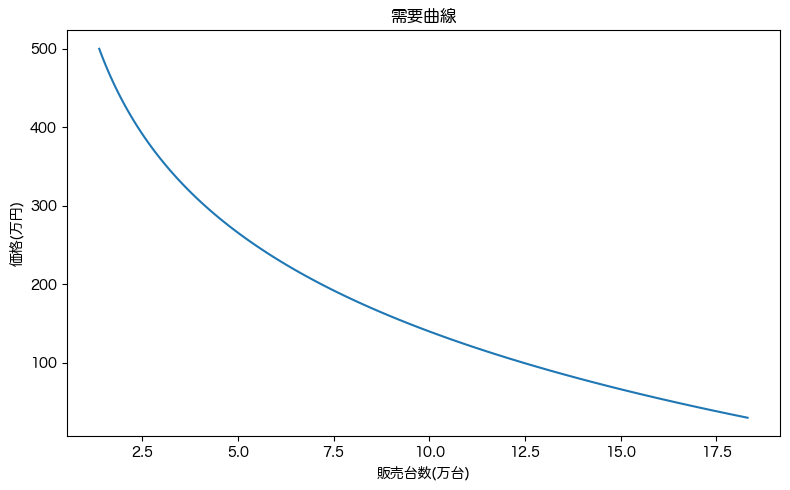

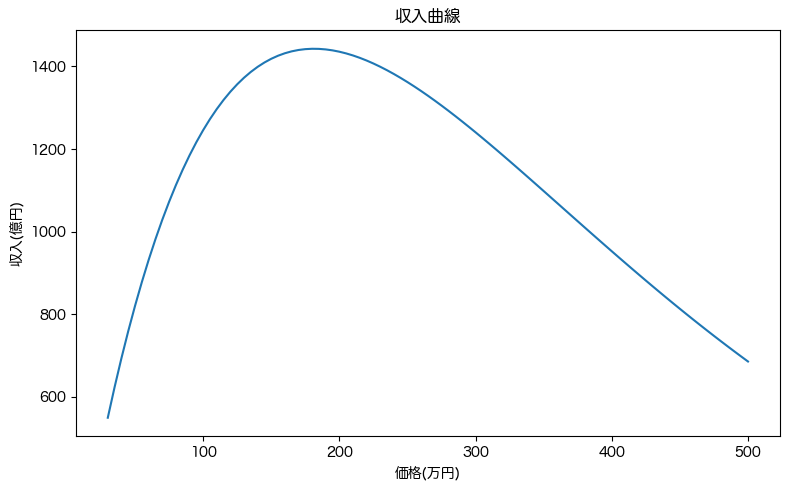

In [8]:
# アプリケーション: 需要曲線と収入曲線
dt_application = data[['NameID', 'year', 'Sales', 'price', 'FuelEfficiency',
                       'size', 'hppw', 'HH', 'share']].copy()
dt_application['xi_fit'] = iv_GH.resids.values

# アルファード
NameID_target = data[(data['Nippyo'] == 1) &
                     (data['Maker'] == 'Toyota') &
                     (data['Name'] == 'アルファード')]['NameID'].unique()[0]

estparam = iv_GH.params

def calculate_sales(price_cand, year, modelID_target, dt, est_param):
    """価格をインプットとして、販売台数を返す関数。"""
    dt_year = dt[dt['year'] == year].copy()
    dt_year['temp_price'] = dt_year['price'].copy()
    dt_year.loc[dt_year['NameID'] == modelID_target, 'temp_price'] = price_cand

    dt_year['delta'] = (est_param['const'] +
                        est_param['price'] * dt_year['temp_price'] +
                        est_param['hppw'] * dt_year['hppw'] +
                        est_param['FuelEfficiency'] * dt_year['FuelEfficiency'] +
                        est_param['size'] * dt_year['size'] +
                        dt_year['xi_fit'])

    denom = 1 + np.exp(dt_year['delta']).sum()
    dt_year['pred_sales'] = (np.exp(dt_year['delta']) / denom) * dt_year['HH']

    return dt_year.loc[dt_year['NameID'] == modelID_target, 'pred_sales'].values[0]

# 需要曲線を描く
pricevec = np.arange(0.30, 5.01, 0.05)
quantvec = np.array([calculate_sales(p, 2016, NameID_target, dt_application, estparam)
                     for p in pricevec])
revenuevec = pricevec * quantvec

# 需要曲線プロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(quantvec / 10000, pricevec * 100)
ax.set_xlabel('販売台数(万台)')
ax.set_ylabel('価格(万円)')
ax.set_title('需要曲線')
plt.tight_layout()
plt.savefig(output_dir / 'fig3_1_demand.png', dpi=150)
plt.show()

# 収入曲線プロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pricevec * 100, revenuevec * 100 / 10000)
ax.set_xlabel('価格(万円)')
ax.set_ylabel('収入(億円)')
ax.set_title('収入曲線')
plt.tight_layout()
plt.savefig(output_dir / 'fig3_1_revenue.png', dpi=150)
plt.show()


In [9]:
# 収入最大化価格を求める
def maximize_revenue(price_cand, year, modelID_target, dt, est_param):
    q = calculate_sales(price_cand, year, modelID_target, dt, est_param)
    return -(price_cand * q)  # minimize negative revenue

result = optimize.minimize_scalar(
    maximize_revenue,
    bounds=(0.3, 3),
    method='bounded',
    args=(2016, NameID_target, dt_application, estparam)
)

print(f"収入を最大にする価格: {result.x * 100:.1f} 万円")
print(f"最大収入: {-result.fun * 100 / 10000:.1f} 億円")

with open(output_dir / 'Ch03_opt_price.txt', 'w') as f:
    f.write(f"Optimal price: {result.x:.6f}\n")
    f.write(f"Maximum revenue: {-result.fun:.6f}\n")


収入を最大にする価格: 181.4 万円
最大収入: 1442.7 億円


## まとめ

In [10]:
print("=" * 60)
print("第3章の分析完了")
print("=" * 60)
print("\n出力ファイル:")
for f in sorted(output_dir.glob('*')):
    if f.name.startswith(('tab3_', 'fig3_', 'Ch03_', 'tbl_ols')):
        print(f"  {f.name}")


第3章の分析完了

出力ファイル:
  Ch03_opt_price.txt
  fig3_1_demand.pdf
  fig3_1_demand.png
  fig3_1_revenue.pdf
  fig3_1_revenue.png
  tab3_1_data_summary.txt
  tab3_2_tbl_logit_iv.txt
  tab3_3_own_elas.txt
  tbl_ols_intro.txt
